<a href="https://colab.research.google.com/github/aahan-charak24/Deep-Learning-Mastery/blob/main/Shallow_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<h2>Activation functions </h2>

In [8]:
#relu
def relu(x):
  return np.maximum(0, x)

#tanh
def tanh(x):
  return np.tanh(x)

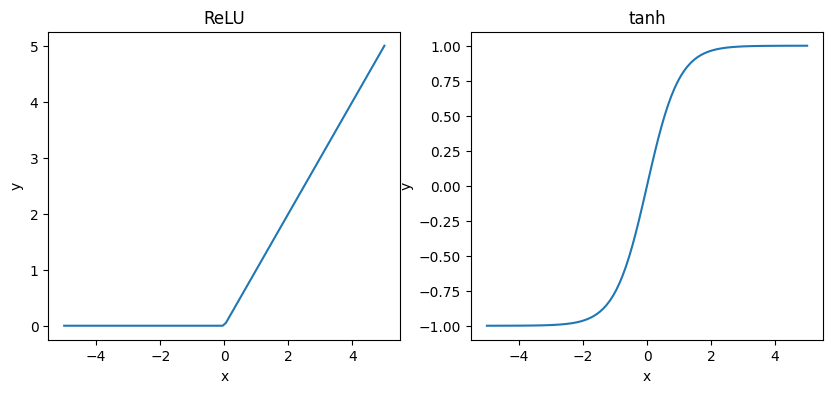

In [14]:
#plotting these functions
x = np.linspace(-5.0, 5.0, num = 100)

y_rel = relu(x)
y_tanh = tanh(x)

fig, axs = plt.subplots(1, 2, figsize = (10, 4))

axs[0].plot(x, y_rel)
axs[0].set_title('ReLU')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

axs[1].plot(x, y_tanh)
axs[1].set_title('tanh')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')

fig.show()

<h2>Shallow NN with three hidden units </h2>

y = $\phi_0 + \phi_1.a[\phi_{10} + \phi_{11}.x] + \phi_2.a[\phi_{20} + \phi_{21}.x] + \phi_3.a[\phi_{30} + \phi_{31}.x]$

Here the terms in the brackets are the activation functions. in this example, a high dimensional input dataset is used just using this small example for intuition. These three hidden units due to relu activation will have regions where they are zero and regions where they are active. the point where they turn to zero are called joints. the resultant function y is a result of combination of these piecewise linear units. In this case three joints, 4 regions. activations are active in a region are called active activations and those that are turned off in that region are called inactive activations. if we have sufficient number of activations we can approximate most non-linear functions.

<h3>Universal Approximation Theorm </h3>
For any continuos function, there exists a shallow nn that can approximate that function to a specific precision

<h3>Cases with multiple outputs </h3>
Both the outputs will have the same joints, as both have the same activations being input to them so same linear regions. But the slopes and vertical offset differ due to the weights being different.

<h2>Load the Dataset</h2>

In [18]:
df = np.loadtxt('/content/pima-indians-diabetes.txt', delimiter = ',')
x = df[:, 0:8]
y = df[:, 8]

In [26]:
#convert to torch tensor
X = torch.tensor(x, dtype = torch.float32)
Y = torch.tensor(y, dtype = torch.float32).view(-1, 1)


In [27]:
import torch.nn as nn
import torch.optim as optim

In [35]:
model = nn.Sequential(
    nn.Linear(8, 3),
    nn.ReLU(),
    nn.Linear(3, 1),
    nn.Sigmoid()
)

<h2>Sigmoid Activation </h2>
Squishes the input between 0 and 1. Used to simulate the lambda probability in binary cross entropy loss. Lambda is the parameter we predict from the model for MLE in binary classification. Lambda represents the probability that output belongs to y = 1 class. So using lambda we have to maximize the probability: <br><br>

$P_r(y|\lambda) = (1-\lambda)^{1-y}.\lambda^{y}$
<br><br>
Which is the probability that given lambda we output the correct y.
<br><br>
Lambda here is the softmax output.

In [36]:
print(model)

Sequential(
  (0): Linear(in_features=8, out_features=3, bias=True)
  (1): ReLU()
  (2): Linear(in_features=3, out_features=1, bias=True)
  (3): Sigmoid()
)


In [37]:
#model class
class SNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.hidden1 = nn.Linear(8, 3)
    self.act1 = nn.ReLU()
    self.output = nn.Linear(3,1)
    self.act_output = nn.Sigmoid()

  #forward pass
  def forward(self, x):
    x = self.act1(self.hidden1(x))
    x = self.act_output(self.output(x))
    return x


model = SNN()

print(model)

SNN(
  (hidden1): Linear(in_features=8, out_features=3, bias=True)
  (act1): ReLU()
  (output): Linear(in_features=3, out_features=1, bias=True)
  (act_output): Sigmoid()
)


In [57]:
#binary corss entropy loss
loss_fn = nn.BCELoss()
# we will use adam optimizer
optimizer = optim.Adam(model.parameters(), lr = 0.00001)



In [61]:
#training the model
n_epochs = 100
batch_size = 5
loss_arr = []
verbose = False

for epoch in range(n_epochs):
  #loop through training set and pass each batch
  loss_batch = []
  for i in range(0, len(X), batch_size):
    Xbatch = X[i : i + batch_size]
    Ybatch = Y[i : i + batch_size]
    y_pred = model(Xbatch)
    loss = loss_fn(y_pred, Ybatch)
    loss_batch.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  loss_arr.append(np.mean(loss_batch))

  if verbose:
    print(f'Epoch {epoch + 1} loss: {loss}')





In [62]:
#output the accuracy
with torch.no_grad():
  y_pred = model(X)

acc = (y_pred.round() == Y).float().mean()
print(f'Accuracy: {acc}')


Accuracy: 0.7864583134651184


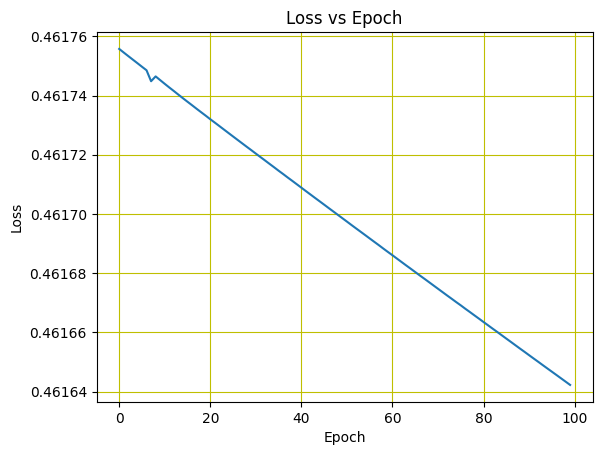

In [63]:

plt.plot(loss_arr)
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid('True', color = 'y')
plt.show()

In [64]:
print(loss_arr)

[np.float64(0.46175574646754697), np.float64(0.46175452278225454), np.float64(0.46175331714284884), np.float64(0.4617521242274866), np.float64(0.4617509316507872), np.float64(0.46174972664032665), np.float64(0.4617485406917411), np.float64(0.46174483485036083), np.float64(0.4617464666242723), np.float64(0.4617452087340417), np.float64(0.46174395205332086), np.float64(0.46174272227209884), np.float64(0.46174152374461097), np.float64(0.461740298269244), np.float64(0.4617390894851127), np.float64(0.46173790242377816), np.float64(0.4617367266834556), np.float64(0.46173553018794433), np.float64(0.46173435875347685), np.float64(0.46173319704346844), np.float64(0.4617319977902747), np.float64(0.46173085277150205), np.float64(0.46172968675563864), np.float64(0.46172851730476727), np.float64(0.46172734732171156), np.float64(0.4617261824185972), np.float64(0.4617250193055574), np.float64(0.46172386098217655), np.float64(0.46172270130414467), np.float64(0.4617215617039761), np.float64(0.461720392